In [1]:
###Load packages###
import pandas as pd
import os
import ast
from scipy import stats
from matplotlib import pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
import numpy as np
import statsmodels.formula.api as smf


###Load cleaned dataset###

#Set file paths
topdir = '/Users/sm6511/Desktop/Prediction-Accomodation-Exp'
study = 'Study5.0'
cleandir = os.path.join(topdir, f'data/{study}/Cleaned')
outputdir = os.path.join(topdir, f'Analysis/{study}')
outputdirCombined = os.path.join(topdir, f'data/Combined')
os.makedirs(outputdir, exist_ok=True)

#Read in cleaned data 
accomodate_path = os.path.join(cleandir, f'{study}Accommodate.csv')
predict_path   = os.path.join(cleandir, f'{study}Predict.csv')

df_accommodate = pd.read_csv(accomodate_path)
df_predict   = pd.read_csv(predict_path)

df_accommodate['task'] = 'accommodate'
df_predict['task']   = 'predict'


print("Accommodate columns:", df_accommodate.columns.tolist())
print("Predict columns:", df_predict.columns.tolist())


Accommodate columns: ['participant', 'free_texts', 'feedback', 'fertility_score', 'trial_stop_time', 'testing_image_order', 'testing_responses', 'training_categories', 'training_feet', 'training_stripes', 'testing_categories', 'conditionOrder', 'training_image_order', 'attention_check', 'cogpro_predict', 'cogpro_explain', 'relevant_dim', 'irrelevant_dim', 'feet_high', 'stripes_low', 'stripes_high', 'feet_low', 'feet_discrete_slider.response', 'feet_direction_slider.response', 'feet_continuous_slider.response', 'feet_discrete_slider_mid.response', 'feet_direction_slider_mid.response', 'feet_continuous_slider_mid.response', 'stripes_discrete_slider.response', 'stripes_direction_slider.response', 'stripes_continuous_slider.response', 'stripes_discrete_slider_mid.response', 'stripes_direction_slider_mid.response', 'stripes_continuous_slider_mid.response', 'task']
Predict columns: ['participant', 'training_responses', 'fertility_score', 'error', 'feedback', 'trial_stop_time', 'testing_image

In [2]:
#Converting string representations of lists back to lists

def parse_list_column(x):
    """take column entries that are strings representing lists and convert them to actual lists"""
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        x = x.strip()
        if x.startswith('[') and x.endswith(']'):
            return ast.literal_eval(x)
        else:
            return [x]
    return []
for col in ['training_feet', 'training_stripes', 'training_image_order', 'training_categories', 'testing_categories']:
    df_accommodate[col] = df_accommodate[col].apply(parse_list_column)
    df_predict[col]   = df_predict[col].apply(parse_list_column)

df_accommodate['testing_responses'] = df_accommodate['testing_responses'].apply(ast.literal_eval)
df_accommodate['fertility_score'] = df_accommodate['fertility_score'].apply(ast.literal_eval)
df_accommodate['testing_image_order'] = df_accommodate['testing_image_order'].apply(ast.literal_eval)
df_accommodate['free_texts'] = df_accommodate['free_texts'].apply(ast.literal_eval)
df_predict['testing_responses'] = df_predict['testing_responses'].apply(ast.literal_eval)
df_predict['fertility_score'] = df_predict['fertility_score'].apply(ast.literal_eval)
df_predict['testing_image_order'] = df_predict['testing_image_order'].apply(ast.literal_eval)
#Combine the dataframes and create an arbitrary column for participant numbering (the yoked orders are already stored in 'conditionOrder')



In [3]:
# Load explanation coding
coding_path = os.path.join(
    topdir,
    "data/Combined/explanationcodes/Explanation_Coding_Study5.csv"
)

df_coding = pd.read_csv(coding_path)

# Drop empty rows
df_coding = df_coding.dropna(subset=["participant"]).copy()

# Convert participant IDs to ints
df_coding["participant"] = df_coding["participant"].astype(int)
df_accommodate["participant"] = df_accommodate["participant"].astype(int)

# Treat blank cells as 0, coded cells as 1
coding_cols = [
    "None",
    "Causal_Explanation",
    "stripes",
    "feet",
    "both",
    "other",
]

for col in coding_cols:
    df_coding[col] = (
        df_coding[col]
        .fillna(0)
        .replace("", 0)
        .astype(int)
    )


# Feature-specific causal indicators
# A tick in "both" means both stripes and feet are causal
df_coding["causal_stripes"] = (
    df_coding["stripes"].eq(1)
    | df_coding["both"].eq(1)
)

df_coding["causal_feet"] = (
    df_coding["feet"].eq(1)
    | df_coding["both"].eq(1)
)


# Another label for type of explanation: "stripes", "feet", "both", or "none"
df_coding["explanation_type"] = np.select(
    [
        df_coding["causal_stripes"] & df_coding["causal_feet"],
        df_coding["causal_stripes"],
        df_coding["causal_feet"],
    ],
    [
        "both",
        "stripes",
        "feet",
    ],
    default="none",
)


# Broad flag that there was a causal explanation of any kind
df_coding["has_causal_explanation"] = (
    df_coding["Causal_Explanation"].eq(1)
    | df_coding["causal_stripes"]
    | df_coding["causal_feet"]
)



# Merge coding onto accommodate data
df_accommodate = df_accommodate.merge(
    df_coding[
        [
            "participant",
            "explanation_type",
            "has_causal_explanation",
            "causal_stripes",
            "causal_feet",
        ]
    ],
    on="participant",
    how="left",
    validate="many_to_one",
)


# Participants not in coding file default to no causal explanation
df_accommodate["explanation_type"] = (
    df_accommodate["explanation_type"]
    .fillna("none")
)

boolean_cols = [
    "has_causal_explanation",
    "causal_stripes",
    "causal_feet",
]

df_accommodate[boolean_cols] = (
    df_accommodate[boolean_cols]
    .fillna(False)
    .astype(bool)
)

In [4]:
df_combined = pd.concat([df_accommodate, df_predict], ignore_index=True)

In [5]:
participant_id = 299

row = df_accommodate.loc[
    df_accommodate['participant'] == participant_id
].iloc[0]

print(f"Participant: {participant_id}")
print(f"Explanation type: {row['explanation_type']}")
print(f"Has causal explanation: {row['has_causal_explanation']}")
print(f"Causal feet: {row['causal_feet']}")
print(f"Causal stripes: {row['causal_stripes']}")
print("\n--- FREE TEXTS ---\n")

for text in row['free_texts']:
    print(text)
    print()

Participant: 299
Explanation type: both
Has causal explanation: True
Causal feet: True
Causal stripes: True

--- FREE TEXTS ---

This reptile’s fertility is related to its striped appearance making it easy to see for mating

This reptile’s fertility is related to its flat feet, allowing it to be more mobile

This reptile has flat toes and feet making it easy to move around to find a mate 

This reptile has curled toes 

This reptile has flat feet and no curled toes

This reptile has flat feet and toes

This reptile has curled toes and large eyes

This reptile has circled toes 

Striped pattern to the right and webbed toes

Striped patter to the left and curled toes

To the left pattern and webbed toes

To the right pattern and curled toes

Left pattern and webbed toes

Right pattern and webbed toes

Right pattern and curled toes

Left pattern and curled toes 



In [6]:
# Compute feature importance scores at midpoint and end
feet_map = {
    "webbed": "f",
    "curved/pointy": "c",
}

stripes_map = {
    "up/right": "e",
    "up/left": "w",
}

feature_maps = {
    "feet": feet_map,
    "stripes": stripes_map,
}

def compute_feature_importance_from_df(df):
    """
    Compute numeric feature-importance scores from -7 to 7 for each participant
    at both the midpoint and the end of the study.

    A score of 0 indicates that:
      - the participant said the feature was not relevant,
      - the participant did not respond, or
      - the selected direction could not be matched to the stored high/low values.

    Creates:
      - feet_importance
      - stripes_importance
      - feet_importance_mid
      - stripes_importance_mid
    """

    df = df.copy()
    features = ["feet", "stripes"]

    def normalize_str(value):
        """Strip whitespace, collapse repeated spaces, and lowercase strings."""
        if isinstance(value, str):
            return " ".join(value.split()).lower()
        return ""

    def compute_row_importance(row, feat, timepoint):
        """
        Compute importance for one feature at either midpoint or end.

        timepoint:
          - "mid"
          - "end"
        """

        suffix = "_mid" if timepoint == "mid" else ""

        disc = row[f"{feat}_discrete_slider{suffix}.response"]
        direction = row[f"{feat}_direction_slider{suffix}.response"]
        continuous = row[f"{feat}_continuous_slider{suffix}.response"]

        # If the participant said the feature was not relevant,
        # or did not answer, importance is zero
        if disc == "No" or pd.isna(disc):
            return 0.0

        # Missing response with a warning
        cont_val = float(continuous) if not pd.isna(continuous) else 0.0

        mapping = feature_maps.get(feat, {})

        direction_norm = normalize_str(direction)
        internal_direction = mapping.get(direction_norm)

        high_val = normalize_str(row[f"{feat}_high"])
        low_val = normalize_str(row[f"{feat}_low"])

        # Positive if selected direction matches the high-value feature
        if internal_direction == high_val:
            sign = 1

        # Negative if selected direction matches the low-value feature
        elif internal_direction == low_val:
            sign = -1

        # Unmatched or missing direction response
        else:
            sign = 0
            cont_val = 0.0

        return cont_val * sign

    # Compute midpoint and end importance for each feature
    for feat in features:
        df[f"{feat}_importance"] = df.apply(
            lambda row: compute_row_importance(
                row,
                feat,
                timepoint="end",
            ),
            axis=1,
        )

        df[f"{feat}_importance_mid"] = df.apply(
            lambda row: compute_row_importance(
                row,
                feat,
                timepoint="mid",
            ),
            axis=1,
        )

    return df

df_combined = compute_feature_importance_from_df(df_combined)


# Create participant-level explanation group:
# predict
# accommodate_causal
# accommodate_none

df_combined["task_explanation_group"] = np.select(
    [
        df_combined["task"].eq("predict"),
        (
            df_combined["task"].eq("accommodate")
            & df_combined["has_causal_explanation"].fillna(False)
        ),
        (
            df_combined["task"].eq("accommodate")
            & ~df_combined["has_causal_explanation"].fillna(False)
        ),
    ],
    [
        "predict",
        "accommodate_causal",
        "accommodate_none",
    ],
    default=pd.NA,
)

df_combined = compute_feature_importance_from_df(df_combined)


# Reshape to long format:
# one row per participant × feature × timepoint

cols_to_keep = [
    "participant",
    "task",
    "task_explanation_group",
    "feet_importance",
    "stripes_importance",
    "feet_importance_mid",
    "stripes_importance_mid",
    "explanation_type",
    "has_causal_explanation",
    "causal_feet",
    "causal_stripes",
    "relevant_dim",
    "irrelevant_dim",
    "feet_high",
    "stripes_high",
    "feet_discrete_slider.response",
]

df_long = df_combined[cols_to_keep].copy()

df_long = df_long.melt(
    id_vars=[
        "participant",
        "task",
        "task_explanation_group",
        "explanation_type",
        "has_causal_explanation",
        "causal_feet",
        "causal_stripes",
        "relevant_dim",
        "irrelevant_dim",
        "feet_high",
        "stripes_high",
        "feet_discrete_slider.response",
    ],
    value_vars=[
        "feet_importance",
        "stripes_importance",
        "feet_importance_mid",
        "stripes_importance_mid",
    ],
    var_name="feature_dimension",
    value_name="feature_importance",
)


# Create time variable 

df_long["time"] = np.where(
    df_long["feature_dimension"].str.endswith("_mid"),
    "mid",
    "end",
)


# Clean feature dimension back to feet/stripes

df_long["feature_dimension"] = (
    df_long["feature_dimension"]
    .str.replace("_importance_mid", "", regex=False)
    .str.replace("_importance", "", regex=False)
)


# Create row-level indicator:
# Did this participant provide a causal explanation for this specific feature?

df_long["had_causal_explanation_for_feature"] = np.select(
    [
        df_long["feature_dimension"].eq("feet"),
        df_long["feature_dimension"].eq("stripes"),
    ],
    [
        df_long["causal_feet"].fillna(False),
        df_long["causal_stripes"].fillna(False),
    ],
    default=False,
).astype(bool)


# Predictors should always be False because they did not provide explanations

df_long["had_causal_explanation_for_feature"] = (
    df_long["had_causal_explanation_for_feature"]
    & df_long["task"].eq("accommodate")
)


# Create feature-relative three-level explanation group

df_long["feature_explanation_group"] = np.select(
    [
        df_long["task"].eq("predict"),
        (
            df_long["task"].eq("accommodate")
            & df_long["had_causal_explanation_for_feature"]
        ),
        (
            df_long["task"].eq("accommodate")
            & ~df_long["had_causal_explanation_for_feature"]
        ),
    ],
    [
        "predictor",
        "explainer",
        "non_explainer",
    ],
    default=pd.NA,
)


# Determine whether the feature represented by the row was relevant

df_long["feature_relevance"] = np.where(
    df_long["feature_dimension"].eq(df_long["relevant_dim"]),
    "relevant",
    "irrelevant",
)


df_long["time"] = pd.Categorical(
    df_long["time"],
    categories=["mid", "end"],
    ordered=True,
)




/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_38828/2033174569.py:124: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & df_combined["has_causal_explanation"].fillna(False)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_38828/2033174569.py:128: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & ~df_combined["has_causal_explanation"].fillna(False)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_38828/2033174569.py:219: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in 

In [7]:
# Check counts by feature, time, and feature-specific explanation group

print(
    df_long.groupby(
        [
            "feature_dimension",
            "time",
            "feature_explanation_group",
        ],
        observed=False,
        dropna=False,
    ).size()
)


# Inspect feature-specific explainers

print(
    df_long.loc[
        df_long["had_causal_explanation_for_feature"],
        [
            "participant",
            "task",
            "feature_dimension",
            "time",
            "causal_feet",
            "causal_stripes",
            "had_causal_explanation_for_feature",
            "feature_explanation_group",
            "feature_importance",
            "feature_relevance",
        ],
    ].sort_values(
        [
            "participant",
            "feature_dimension",
            "time",
        ]
    )
)

feature_dimension  time  feature_explanation_group
feet               mid   explainer                     38
                         non_explainer                254
                         predictor                    292
                   end   explainer                     38
                         non_explainer                254
                         predictor                    292
stripes            mid   explainer                     34
                         non_explainer                258
                         predictor                    292
                   end   explainer                     34
                         non_explainer                258
                         predictor                    292
dtype: int64
      participant         task feature_dimension time causal_feet  \
1336           26  accommodate              feet  mid        True   
168            26  accommodate              feet  end        True   
1194           27  accommodate   

In [8]:
df_long.to_csv(os.path.join(outputdirCombined, 'df_long_by_explanation_for_R-Study5.csv'), index=False)

In [9]:
# Features 
features = ["feet", "stripes"]

# End-of-study columns have no suffix.
# Midpoint columns use "_mid".
timepoints = {
    "mid": "_mid",
    "end": "",
}


#Values are both timepoints 

for time, suffix in timepoints.items():
    print(f"\n{'=' * 50}")
    print(f"{time.upper()} RESPONSE VALUES")
    print(f"{'=' * 50}")

    for feat in features:
        response_col = (
            f"{feat}_discrete_slider{suffix}.response"
        )

        print(f"\nValues in {response_col}:")
        print(
            df_combined[response_col]
            .value_counts(dropna=False)
        )


MID RESPONSE VALUES

Values in feet_discrete_slider_mid.response:
feet_discrete_slider_mid.response
Yes    429
No     155
Name: count, dtype: int64

Values in stripes_discrete_slider_mid.response:
stripes_discrete_slider_mid.response
Yes    412
No     172
Name: count, dtype: int64

END RESPONSE VALUES

Values in feet_discrete_slider.response:
feet_discrete_slider.response
Yes    474
No     110
Name: count, dtype: int64

Values in stripes_discrete_slider.response:
stripes_discrete_slider.response
Yes    460
No     124
Name: count, dtype: int64


In [10]:
# Convert Yes/No responses into 1/0 indicators
for time, suffix in timepoints.items():
    for feat in features:

        response_col = (
            f"{feat}_discrete_slider{suffix}.response"
        )

        endorsed_col = (
            f"{feat}_endorsed_{time}"
        )

        df_combined[endorsed_col] = (
            df_combined[response_col]
            .astype("string")
            .str.strip()
            .str.lower()
            .eq("yes")
            .astype(int)
        )


#Features endorsed at each timepoint

df_combined["n_features_endorsed_mid"] = (
    df_combined["feet_endorsed_mid"]
    + df_combined["stripes_endorsed_mid"]
)

df_combined["n_features_endorsed_end"] = (
    df_combined["feet_endorsed_end"]
    + df_combined["stripes_endorsed_end"]
)


#Explanation groups

df_combined["explanation_group"] = np.select(
    [
        df_combined["task"].eq("predict"),

        (
            df_combined["task"].eq("accommodate")
            & df_combined[
                "has_causal_explanation"
            ].fillna(False)
        ),

        (
            df_combined["task"].eq("accommodate")
            & ~df_combined[
                "has_causal_explanation"
            ].fillna(False)
        ),
    ],
    [
        "Predictor",
        "Explainer",
        "Non-explainer",
    ],
    default=pd.NA,
)


# Create unique participant × task identifier
df_combined["participant_task_id"] = (
    df_combined["participant"].astype(str)
    + "_"
    + df_combined["task"].astype(str)
)


#Participant x timepoint dataframe

overfit_df = df_combined[
    [
        "participant",
        "participant_task_id",
        "task",
        "explanation_group",
        "relevant_dim",
        "irrelevant_dim",

        "feet_endorsed_mid",
        "stripes_endorsed_mid",
        "n_features_endorsed_mid",

        "feet_endorsed_end",
        "stripes_endorsed_end",
        "n_features_endorsed_end",
    ]
].copy()


overfit_long = pd.concat(
    [
        overfit_df[
            [
                "participant",
                "participant_task_id",
                "task",
                "explanation_group",
                "relevant_dim",
                "irrelevant_dim",
                "feet_endorsed_mid",
                "stripes_endorsed_mid",
                "n_features_endorsed_mid",
            ]
        ]
        .rename(
            columns={
                "feet_endorsed_mid": "feet_endorsed",
                "stripes_endorsed_mid": "stripes_endorsed",
                "n_features_endorsed_mid":
                    "n_features_endorsed",
            }
        )
        .assign(time="mid"),

        overfit_df[
            [
                "participant",
                "participant_task_id",
                "task",
                "explanation_group",
                "relevant_dim",
                "irrelevant_dim",
                "feet_endorsed_end",
                "stripes_endorsed_end",
                "n_features_endorsed_end",
            ]
        ]
        .rename(
            columns={
                "feet_endorsed_end": "feet_endorsed",
                "stripes_endorsed_end": "stripes_endorsed",
                "n_features_endorsed_end":
                    "n_features_endorsed",
            }
        )
        .assign(time="end"),
    ],
    ignore_index=True,
)

overfit_long["time"] = pd.Categorical(
    overfit_long["time"],
    categories=["mid", "end"],
    ordered=True,
)


print(
    overfit_long[
        [
            "participant_task_id",
            "explanation_group",
            "time",
            "feet_endorsed",
            "stripes_endorsed",
            "n_features_endorsed",
        ]
    ].head(10)
)

  participant_task_id explanation_group time  feet_endorsed  stripes_endorsed  \
0     226_accommodate     Non-explainer  mid              0                 0   
1     210_accommodate     Non-explainer  mid              1                 1   
2     269_accommodate         Explainer  mid              1                 1   
3     215_accommodate     Non-explainer  mid              1                 0   
4      83_accommodate     Non-explainer  mid              0                 0   
5     171_accommodate     Non-explainer  mid              1                 0   
6     157_accommodate         Explainer  mid              1                 1   
7       1_accommodate     Non-explainer  mid              1                 1   
8     122_accommodate     Non-explainer  mid              1                 1   
9     149_accommodate     Non-explainer  mid              1                 1   

   n_features_endorsed  
0                    0  
1                    2  
2                    2  
3       

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_38828/3104571341.py:46: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ].fillna(False)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_38828/3104571341.py:53: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ].fillna(False)


In [11]:
# Plotting order
group_order = [
    "Predictor",
    "Non-explainer",
    "Explainer",
]

score_order = [0, 1, 2]


# Count participants at each score within each group and timepoint
overfit_percentages = (
    overfit_long
    .dropna(
        subset=[
            "explanation_group",
            "time",
            "n_features_endorsed",
        ]
    )
    .groupby(
        [
            "time",
            "explanation_group",
            "n_features_endorsed",
        ],
        observed=True,
    )
    .agg(
        n_participants=(
            "participant_task_id",
            "nunique",
        )
    )
    .reset_index()
)


# Add missing time × group × score combinations as zeros
full_index = pd.MultiIndex.from_product(
    [
        ["mid", "end"],
        group_order,
        score_order,
    ],
    names=[
        "time",
        "explanation_group",
        "n_features_endorsed",
    ],
)

overfit_percentages = (
    overfit_percentages
    .set_index(
        [
            "time",
            "explanation_group",
            "n_features_endorsed",
        ]
    )
    .reindex(
        full_index,
        fill_value=0,
    )
    .reset_index()
)


# Calculate percentage within each time × explanation group
overfit_percentages["percentage"] = (
    overfit_percentages["n_participants"]
    / overfit_percentages
        .groupby(
            [
                "time",
                "explanation_group",
            ]
        )["n_participants"]
        .transform("sum")
    * 100
)

print(overfit_percentages)

   time explanation_group  n_features_endorsed  n_participants  percentage
0   mid         Predictor                    0              24    8.219178
1   mid         Predictor                    1             103   35.273973
2   mid         Predictor                    2             165   56.506849
3   mid     Non-explainer                    0              26   10.569106
4   mid     Non-explainer                    1              94   38.211382
5   mid     Non-explainer                    2             126   51.219512
6   mid         Explainer                    0               5   10.869565
7   mid         Explainer                    1              20   43.478261
8   mid         Explainer                    2              21   45.652174
9   end         Predictor                    0              19    6.506849
10  end         Predictor                    1              84   28.767123
11  end         Predictor                    2             189   64.726027
12  end     Non-explainer

In [12]:
def plot_overfit_percentages(
    percentage_df,
    timepoint,
    group_order,
    score_order,
):
    """
    Plot a horizontal 100% stacked bar chart showing the
    percentage of participants endorsing 0, 1, or 2 features
    at a selected timepoint.
    """

    plot_df = (
        percentage_df
        .loc[
            percentage_df["time"].eq(timepoint)
        ]
        .copy()
    )

    # Participant counts in wide format
    count_wide = (
        plot_df
        .pivot(
            index="explanation_group",
            columns="n_features_endorsed",
            values="n_participants",
        )
        .reindex(group_order)
        .reindex(
            columns=score_order,
            fill_value=0,
        )
        .fillna(0)
    )

    # Percentages in wide format
    percentage_wide = (
        plot_df
        .pivot(
            index="explanation_group",
            columns="n_features_endorsed",
            values="percentage",
        )
        .reindex(group_order)
        .reindex(
            columns=score_order,
            fill_value=0,
        )
        .fillna(0)
    )

    fig, ax = plt.subplots(
        figsize=(9, 4.5)
    )

    left = np.zeros(
        len(percentage_wide)
    )

    for score in score_order:
        percentages = (
            percentage_wide[score]
            .to_numpy()
        )

        counts = (
            count_wide[score]
            .to_numpy()
        )

        bars = ax.barh(
            y=percentage_wide.index,
            width=percentages,
            left=left,
            edgecolor="black",
            label=f"{score} features",
        )

        for (
            bar,
            percentage,
            count,
            starting_point,
        ) in zip(
            bars,
            percentages,
            counts,
            left,
        ):
            if percentage >= 8:
                ax.text(
                    starting_point
                    + percentage / 2,
                    bar.get_y()
                    + bar.get_height() / 2,
                    (
                        f"{percentage:.1f}%\n"
                        f"(n={int(count)})"
                    ),
                    ha="center",
                    va="center",
                    fontsize=9,
                )

            elif percentage > 0:
                ax.text(
                    starting_point
                    + percentage / 2,
                    bar.get_y()
                    + bar.get_height() / 2,
                    f"{percentage:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=8,
                )

        left += percentages

    ax.set_xlim(0, 100)

    ax.set_xlabel(
        "Percentage of participants"
    )

    ax.set_ylabel(
        "Explanation group"
    )

    ax.set_xticks(
        np.arange(0, 101, 20)
    )

    ax.set_title(
        f"Features judged relevant at {timepoint}"
    )

    ax.invert_yaxis()

    ax.legend(
        title="Model complexity",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

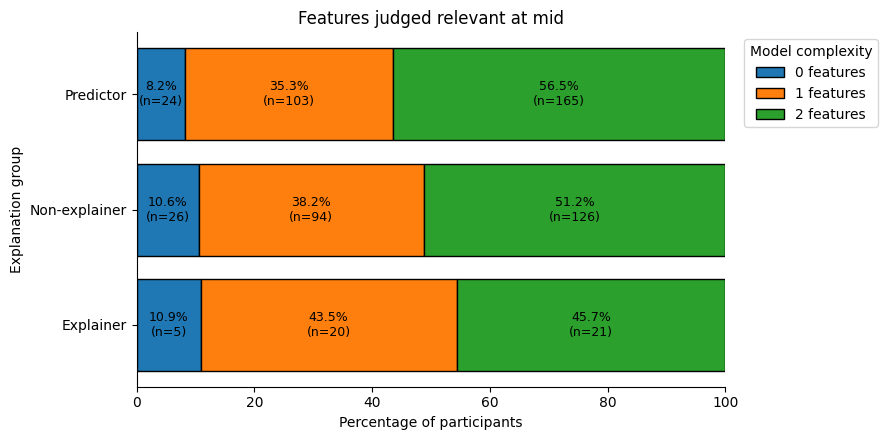

In [15]:
# Midpoint plot
plot_overfit_percentages(
    percentage_df=overfit_percentages,
    timepoint="mid",
    group_order=group_order,
    score_order=score_order,
)

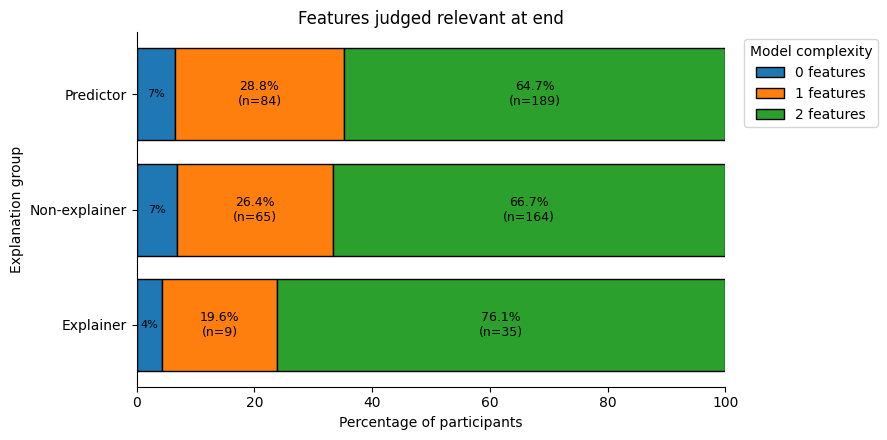

In [13]:
# End-of-study plot
plot_overfit_percentages(
    percentage_df=overfit_percentages,
    timepoint="end",
    group_order=group_order,
    score_order=score_order,
)

In [14]:
# ---------------------------------------------------------
# Subdivide the one-feature category by feature, separately
# for midpoint and end
# ---------------------------------------------------------

overfit_long["endorsement_pattern"] = np.select(
    [
        overfit_long["n_features_endorsed"].eq(0),

        (
            overfit_long["n_features_endorsed"].eq(1)
            & overfit_long["feet_endorsed"].eq(1)
        ),

        (
            overfit_long["n_features_endorsed"].eq(1)
            & overfit_long["stripes_endorsed"].eq(1)
        ),

        overfit_long["n_features_endorsed"].eq(2),
    ],
    [
        "0 features",
        "1: feet",
        "1: stripes",
        "2 features",
    ],
    default=pd.NA,
)


group_order = [
    "Predictor",
    "Non-explainer",
    "Explainer",
]

pattern_order = [
    "0 features",
    "1: feet",
    "1: stripes",
    "2 features",
]

time_order = ["mid", "end"]


# Count participants within each time × group × pattern
pattern_percentages = (
    overfit_long
    .dropna(
        subset=[
            "time",
            "explanation_group",
            "endorsement_pattern",
        ]
    )
    .groupby(
        [
            "time",
            "explanation_group",
            "endorsement_pattern",
        ],
        observed=True,
    )
    .agg(
        n_participants=(
            "participant_task_id",
            "nunique",
        )
    )
    .reset_index()
)


# Add missing time × group × pattern combinations as zero
full_index = pd.MultiIndex.from_product(
    [
        time_order,
        group_order,
        pattern_order,
    ],
    names=[
        "time",
        "explanation_group",
        "endorsement_pattern",
    ],
)

pattern_percentages = (
    pattern_percentages
    .set_index(
        [
            "time",
            "explanation_group",
            "endorsement_pattern",
        ]
    )
    .reindex(
        full_index,
        fill_value=0,
    )
    .reset_index()
)


# Calculate percentages separately within each time × group
group_totals = (
    pattern_percentages
    .groupby(
        [
            "time",
            "explanation_group",
        ]
    )["n_participants"]
    .transform("sum")
)

pattern_percentages["percentage"] = np.where(
    group_totals > 0,
    (
        pattern_percentages["n_participants"]
        / group_totals
        * 100
    ),
    0,
)

print(pattern_percentages)

   time explanation_group endorsement_pattern  n_participants  percentage
0   mid         Predictor          0 features              24    8.219178
1   mid         Predictor             1: feet              56   19.178082
2   mid         Predictor          1: stripes              47   16.095890
3   mid         Predictor          2 features             165   56.506849
4   mid     Non-explainer          0 features              26   10.569106
5   mid     Non-explainer             1: feet              44   17.886179
6   mid     Non-explainer          1: stripes              50   20.325203
7   mid     Non-explainer          2 features             126   51.219512
8   mid         Explainer          0 features               5   10.869565
9   mid         Explainer             1: feet              17   36.956522
10  mid         Explainer          1: stripes               3    6.521739
11  mid         Explainer          2 features              21   45.652174
12  end         Predictor          0 f

In [15]:
def plot_endorsement_patterns(
    percentage_df,
    timepoint,
    group_order,
    pattern_order,
):
    """
    Plot the percentages endorsing neither feature, feet only,
    stripes only, or both features at one timepoint.
    """

    plot_df = (
        percentage_df
        .loc[
            percentage_df["time"].eq(timepoint)
        ]
        .copy()
    )

    count_wide = (
        plot_df
        .pivot(
            index="explanation_group",
            columns="endorsement_pattern",
            values="n_participants",
        )
        .reindex(group_order)
        .reindex(
            columns=pattern_order,
            fill_value=0,
        )
        .fillna(0)
    )

    percentage_wide = (
        plot_df
        .pivot(
            index="explanation_group",
            columns="endorsement_pattern",
            values="percentage",
        )
        .reindex(group_order)
        .reindex(
            columns=pattern_order,
            fill_value=0,
        )
        .fillna(0)
    )

    fig, ax = plt.subplots(figsize=(10, 4.5))

    left = np.zeros(len(percentage_wide))

    for pattern in pattern_order:
        percentages = percentage_wide[pattern].to_numpy()
        counts = count_wide[pattern].to_numpy()

        bars = ax.barh(
            y=percentage_wide.index,
            width=percentages,
            left=left,
            edgecolor="black",
            label=pattern,
        )

        for bar, percentage, count, starting_point in zip(
            bars,
            percentages,
            counts,
            left,
        ):
            center = starting_point + percentage / 2

            if percentage >= 10:
                ax.text(
                    center,
                    bar.get_y() + bar.get_height() / 2,
                    f"{percentage:.1f}%\n(n={int(count)})",
                    ha="center",
                    va="center",
                    fontsize=9,
                )

            elif percentage >= 4:
                ax.text(
                    center,
                    bar.get_y() + bar.get_height() / 2,
                    f"{percentage:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=8,
                )

        left += percentages

    ax.set_xlim(0, 100)
    ax.set_xlabel("Percentage of participants")
    ax.set_ylabel("Explanation group")
    ax.set_xticks(np.arange(0, 101, 20))
    ax.set_title(
        f"Features judged relevant at {timepoint}"
    )

    ax.invert_yaxis()

    ax.legend(
        title="Endorsement pattern",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

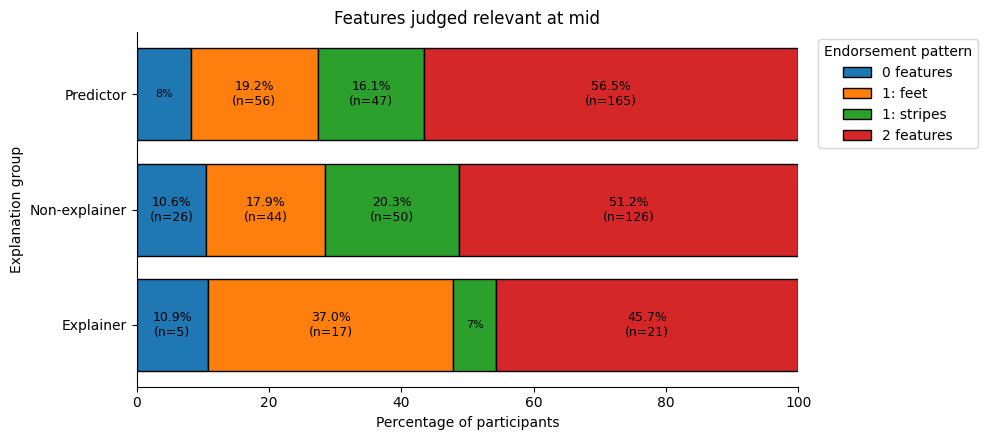

In [16]:
plot_endorsement_patterns(
    percentage_df=pattern_percentages,
    timepoint="mid",
    group_order=group_order,
    pattern_order=pattern_order,
)

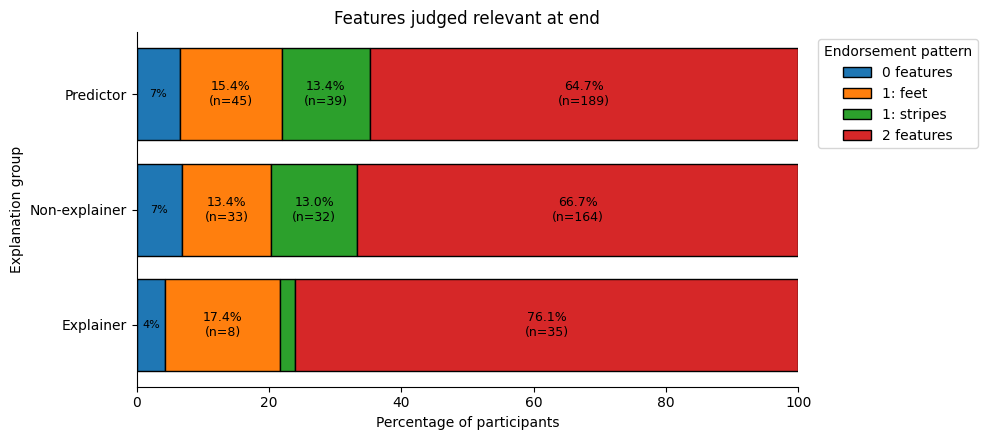

In [17]:
plot_endorsement_patterns(
    percentage_df=pattern_percentages,
    timepoint="end",
    group_order=group_order,
    pattern_order=pattern_order,
)

In [18]:
# Get testingresponses
df = df_combined[
    [
        "task",
        "conditionOrder",
        "testing_image_order",
        "testing_responses",
        "relevant_dim",
        "irrelevant_dim",
        "stripes_high",
        "feet_high",
        "explanation_type",
        "has_causal_explanation",
        "causal_stripes",
        "causal_feet",
    ]
].copy()

df_long2 = (
    df
    .explode(
        [
            "testing_image_order",
            "testing_responses",
        ]
    )
    .rename(
        columns={
            "testing_image_order": "item"
        }
    )
)

avg_food_test = df_long2.copy()

In [19]:
# Average training fertility score per item
df = df_combined[
    [
        "task",
        "training_image_order",
        "fertility_score",
        "conditionOrder",
    ]
].copy()

df_long2 = (
    df
    .explode(
        [
            "training_image_order",
            "fertility_score",
        ]
    )
    .rename(
        columns={
            "training_image_order": "item"
        }
    )
)

avg_food_train = (
    df_long2
    .groupby(
        [
            "task",
            "conditionOrder",
            "item",
        ],
        as_index=False,
    )["fertility_score"]
    .mean()
)

In [20]:
df_merged = avg_food_test.merge(#merge test and training fertility scores
    avg_food_train,
    on=[
        "task",
        "conditionOrder",
        "item",
    ],
    how="left",
    validate="many_to_one",
)

In [21]:
df_merged["testing_responses"] = pd.to_numeric(
    df_merged["testing_responses"],
    errors="coerce",
)

df_merged["fertility_score"] = pd.to_numeric(
    df_merged["fertility_score"],
    errors="coerce",
)

df_merged["error"] = (
    df_merged["testing_responses"]
    - df_merged["fertility_score"]
)

df_merged["abs_error"] = df_merged["error"].abs()

df_merged[["stripes", "feet"]] = (
    df_merged["item"]
    .str.split("_", expand=True)
)

df_merged["stripes_match_high"] = (
    df_merged["stripes"] == df_merged["stripes_high"]
).astype(int)

df_merged["feet_match_high"] = (
    df_merged["feet"] == df_merged["feet_high"]
).astype(int)

In [22]:
output_path = os.path.join(
    topdir,
    "data/Combined/df_merged_for_R-Study5.csv"
)

df_merged.to_csv(
    output_path,
    index=False,
)

In [23]:
participant_corrs = []

for (task, condition_order), g in df_merged.groupby(
    ["task", "conditionOrder"]
):
    for feat in ["stripes", "feet"]:

        match_col = f"{feat}_match_high"
        causal_col = f"causal_{feat}"
        high_col = f"{feat}_high"

        # Correlation between testing response and matching
        # the high value of this feature
        corr = g["testing_responses"].corr(
            g[match_col]
        )

        # Is this feature relevant for this participant?
        relevant = (
            g["relevant_dim"].iloc[0] == feat
        )

        # Did the participant explain this particular feature?
        had_causal_explanation_for_feature = bool(
            g[causal_col]
            .fillna(False)
            .iloc[0]
        )

        # Feature-relative explanation group
        if task == "predict":
            feature_explanation_group = "predictor"

        elif had_causal_explanation_for_feature:
            feature_explanation_group = "explainer"

        else:
            feature_explanation_group = "non_explainer"

        participant_corrs.append(
            {
                "participant": condition_order,
                "task": task,
                "explanation_type": (
                    g["explanation_type"].iloc[0]
                ),
                "has_causal_explanation": bool(
                    g["has_causal_explanation"]
                    .fillna(False)
                    .iloc[0]
                ),
                "had_causal_explanation_for_feature":
                    had_causal_explanation_for_feature,
                "feature_explanation_group":
                    feature_explanation_group,
                "feature_dimension": feat,
                "high_value": g[high_col].iloc[0],
                "feature_relevance": (
                    "relevant"
                    if relevant
                    else "irrelevant"
                ),
                "correlation": corr,
                "irrelevant_dim": (
                    g["irrelevant_dim"].iloc[0]
                ),
                "abs_correlation": (
                    abs(corr)
                    if pd.notna(corr)
                    else np.nan
                ),
            }
        )

df_corr = pd.DataFrame(participant_corrs)

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_38828/1856406433.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_38828/1856406433.py:49: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3

In [24]:
df_corr.to_csv(os.path.join(outputdirCombined, 'df_corr_by_explanation_for_R-Study5.csv'), index=False)